# Hybrid linear model plots generation

## Imports

In [5]:
%load_ext autoreload
%load_ext rpy2.ipython
%autoreload 2
%reload_ext autoreload
import multiprocessing as mp
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pandas.io.parsers import read_csv
import pylab
from itertools import product
from sklearn.metrics import auc
from hybrids import hyb_lin, max_pareto_front
import matplotlib.pyplot as plt
%matplotlib inline
pylab.rcParams['figure.figsize'] = (5, 5)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


## Data reading

In [6]:
blackbox = 'rf'  # Random forest
# blackbox = 'ab'  # AdaBoosted decision trees
# blackbox = 'xg'  # XGboost (gbtree)

In [7]:
path = './datasets/census/'; name = 'census'

# path = './datasets/coupon/'; name = 'coupon'

# path = './datasets/stop&frisk/'; name = 'stop-and-frisk'

In [8]:
normalize = True

# read data
Xtrain = read_csv(path + 'train.csv',header = 0, sep = ',')
Xtest = read_csv(path + 'test.csv',header = 0, sep = ',')
bbm = read_csv(path + blackbox + '_ybtrain.csv',header = 0,sep = ',')
Ybtrain = np.array(bbm['Yb'])
bbm = read_csv(path + blackbox + '_ybtest.csv',header = 0,sep = ',')
Ybtest = np.array(bbm['Yb'])

ntrain = Xtrain.shape[0]
df = pd.concat([Xtrain, Xtest])
# Seperate Y (answers) from dataframe
Y = np.array(df['Y'])
df.drop(['Y'], axis = 1, inplace = True) 
numericals = [col for col in Xtrain.columns if Xtrain[col].dtype in [int, float] and (~Xtrain[col].isin([0, 1])).any()]

if normalize:
    # Normalize data
    df = df.astype({col: float for col in numericals})
    mean = Xtrain.loc[:, numericals].mean(axis=0)
    std = Xtrain.loc[:, numericals].std(axis=0) + 1e-8
    df.loc[:, numericals] = (df.loc[:, numericals] - mean) / std


ntrain = Xtrain.shape[0]
Ytrain = Y[:ntrain]
Ytest = Y[ntrain:]
Xtrain = df[:ntrain]
Xtest = df[ntrain:]


## Train hybrid linear models
MOZEK optimizer was used for `prob.solve()` as it defauted to MOZEK in my case

In [9]:
# Just like in paper
alpha_1_choices = [0, 0.001, 0.005, 0.01, 0.05, 0.1]
# How does Wang and Lin paper get away with alpha_2 < 0 ??
# Probably due to stopping after 1000 iterations...
# CVXPY will just say "unbounded" so we won't do [-0.1, 0)
alpha_2_choices = np.linspace(0, 0.1, 30, True)

def fit_one(tup):
    model = hyb_lin()
    al1, al2 = tup
    model.fit(Xtrain, Ytrain, Ybtrain, al1, al2)
    if model.w is not None:
        print(f"alpha_1: {al1}, alpha_2: {al2}")
        print("weights: ")
        print(model.w)
        return model
    else:
        return None

params = product(alpha_1_choices, alpha_2_choices)

ctx = mp.get_context("fork")   
with ctx.Pool(processes=16) as pool:
    models = pool.map(fit_one, params)
while None in models:
    models.remove(None)

/usr/local/lib/python3.14/multiprocessing/popen_fork.py:70: DeprecationWarning: This process (pid=1505569) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/usr/local/lib/python3.14/multiprocessing/popen_fork.py:70: DeprecationWarning: This process (pid=1505569) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/usr/local/lib/python3.14/multiprocessing/popen_fork.py:70: DeprecationWarning: This process (pid=1505569) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/usr/local/lib/python3.14/multiprocessing/popen_fork.py:70: DeprecationWarning: This process (pid=1505569) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/usr/local/lib/python3.14/multiprocessing/popen_fork.py:70: DeprecationWarning: This process (pid=1505569) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/usr/

alpha_1: 0.001, alpha_2: 0.031034482758620693
weights: 
[ 3.43697566e-01  5.73995459e-02  7.55695091e-01  2.10723007e+00
  2.50493995e-01  3.64711402e-01 -8.81171989e-09  3.51918234e-01
  0.00000000e+00  0.00000000e+00  4.98309574e-02  9.22039351e-02
 -3.11500632e-01  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00 -3.80848958e-02  0.00000000e+00
  0.00000000e+00  0.00000000e+00 -1.85560045e-09  0.00000000e+00
  0.00000000e+00  0.00000000e+00  3.17623414e-02  0.00000000e+00
  0.00000000e+00  1.78355576e+00  0.00000000e+00 -3.81813272e-01
  0.00000000e+00  0.00000000e+00 -3.35776097e-01  0.00000000e+00
  0.00000000e+00  6.56927327e-03  7.02097629e-01 -6.48042443e-01
 -2.49910910e-01 -9.98134821e-02 -5.74344226e-01  0.00000000e+00
  4.07991609e-01  1.23994492e-01  1.86734669e-01  3.44529753e-01
  0.00000000e+00  0.00000000e+00  9.60521781e-09 -1.27486640e-10
 -6.72485715e-01 -1.03342877e-10  

### Predict with the trained hybrid linear models

In [10]:
results = []
weights = []
test_num = len(Ytest)

for model in models:
    Yhat, covered = model.predict(Xtest, Ybtest)
    covered_amount = len(covered)
    correct_amount = np.count_nonzero(Yhat == Ytest)
    
    transparency = covered_amount / test_num
    accuracy = correct_amount / test_num
    results.append({
        'alpha_1': model.alpha_1,
        'alpha_2': model.alpha_2,
        'transparency': transparency,
        'accuracy': accuracy,
        'features_used': model.used_features  # Amount zero weights
    })
    weights.append(model.w)

weights.sort(key = lambda w: w.astype(bool).sum())
weights = np.array(weights)


## Plot predictions using minimized results

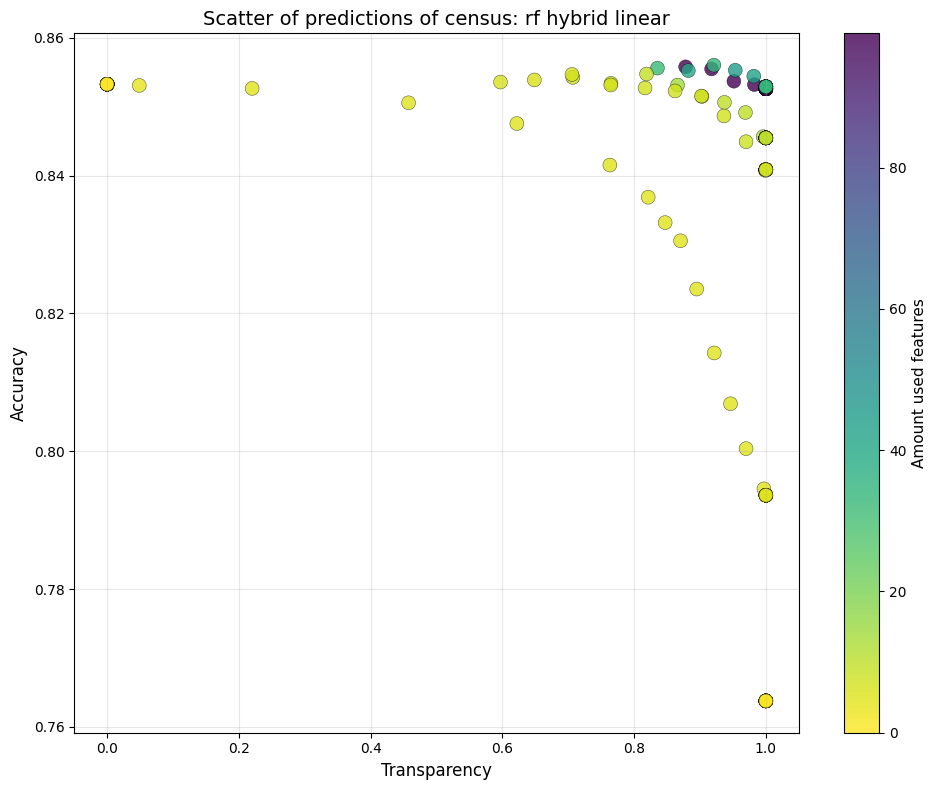

In [11]:
# Save as csv
results_df = pd.DataFrame(results)
# results_df.to_csv(path + f"{name}_{blackbox}_hyblin_results.csv", index=False)
# np.save(path + f'{name}_{blackbox}_hyblin_weights.npy', weights)
# np.savetxt(path + f'{name}_{blackbox}_hyblin_weights.txt', weights)

# Create the plot
plt.figure(figsize=(10, 8))

features_vals = [result['features_used'] for result in results]
transparency_vals = [result['transparency'] for result in results]
accuracy_vals = [result['accuracy'] for result in results]

scatter = plt.scatter(
    transparency_vals,
    accuracy_vals,
    c=features_vals,
    cmap='viridis_r',
    s=100,
    alpha=0.8,
    edgecolors='black',
    linewidths=0.3,
 )

cbar = plt.colorbar(scatter)
cbar.set_label('Amount used features', fontsize=11)

plt.xlabel('Transparency', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title(f'Scatter of predictions of {name}: {blackbox} hybrid linear', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xlim(-0.05, 1.05)
plt.tight_layout()
# plt.savefig(path + f'{name}_{blackbox}_hyblin_scatter.svg')
plt.show()

#### Pareto front with unlimited features

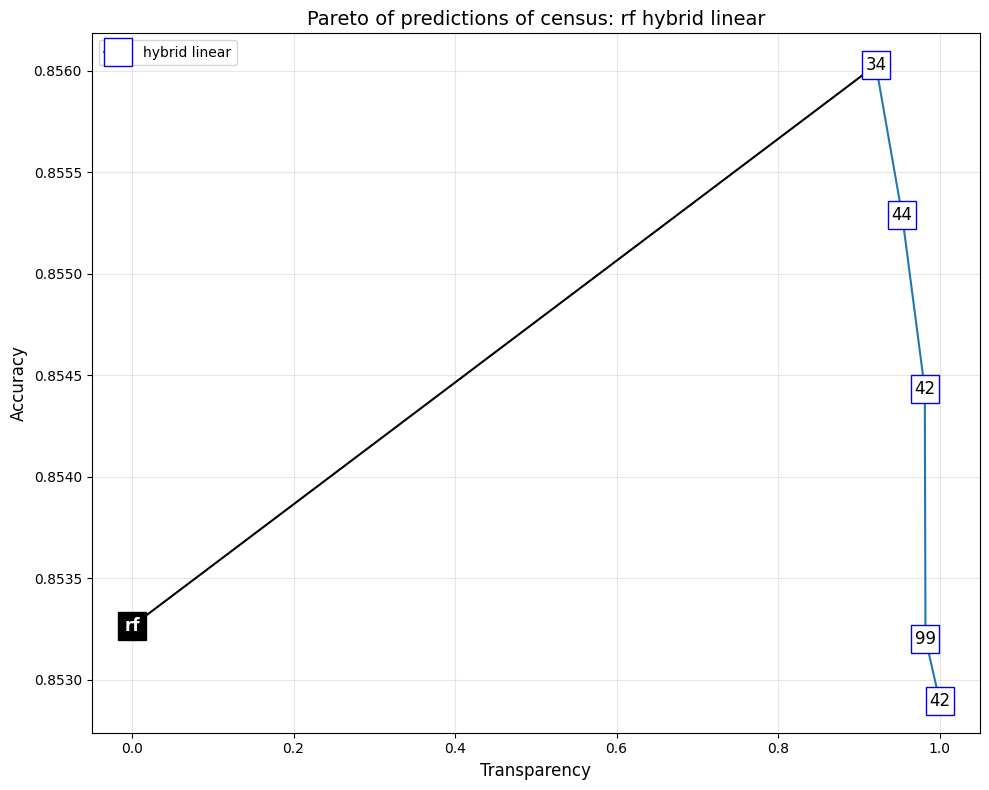

In [12]:
maxpf_df = max_pareto_front(results_df, "transparency", "accuracy")
yb_accuracy = (Ybtest == Ytest).mean()
# Create the plot
plt.figure(figsize=(10, 8))


axes = plt.gca()
plt.plot([0, maxpf_df.iloc[-1]["transparency"]], [yb_accuracy, maxpf_df.iloc[-1]["accuracy"]], color="black")
axes = maxpf_df.plot(x="transparency", y="accuracy", ax=axes, marker='s', markersize=20, markerfacecolor='white', markeredgecolor='blue', label="hybrid linear")
plt.plot(0, yb_accuracy, 's', markersize=20, markerfacecolor='black', markeredgecolor='black')
for i, row in maxpf_df.iterrows():
    plt.text(row["transparency"], row["accuracy"], int(row["features_used"]), 
             ha='center', 
             va='center', 
             fontsize=12, 
             color='black', 
             )
plt.text(0, yb_accuracy, blackbox,
         ha='center', 
         va='center', 
         fontsize=12, 
         fontweight="bold",
         color="white")
plt.xlabel('Transparency', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title(f'Pareto of predictions of {name}: {blackbox} hybrid linear', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xlim(-0.05, 1.05)
plt.tight_layout()
# plt.savefig(path + f'{name}_{blackbox}_hyblin_pareto.svg')
plt.show()

#### Pareto front with dataframe filtered by amount of features used

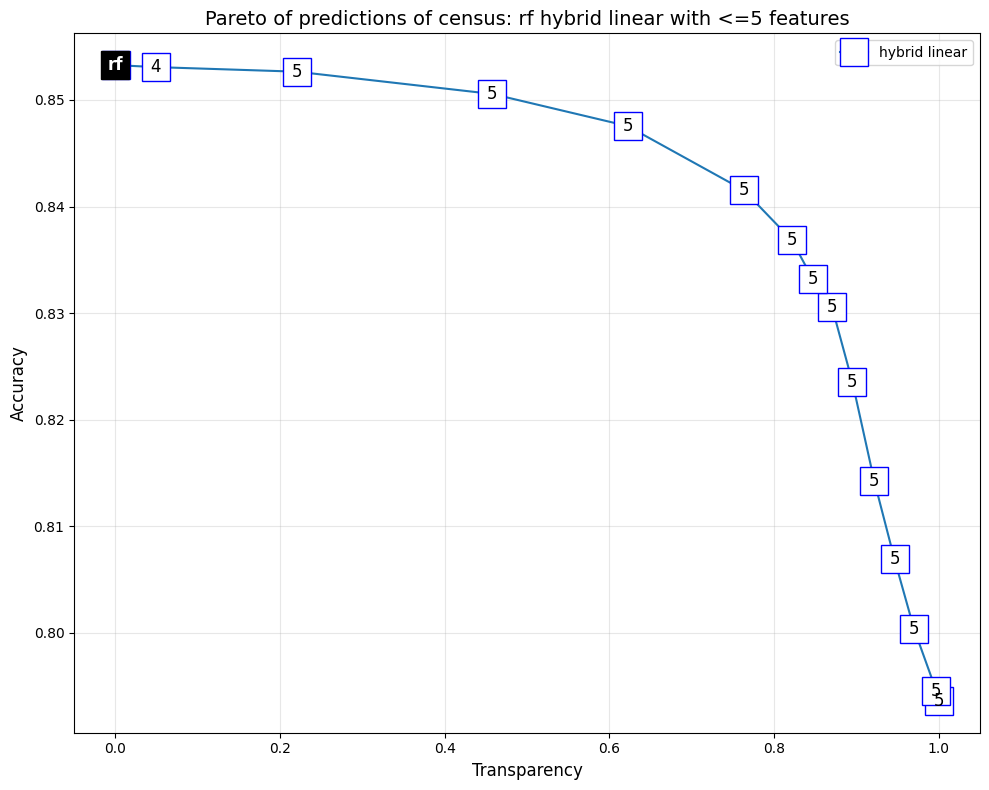

In [13]:
le_feature = 5
maxpf_df = max_pareto_front(results_df[results_df["features_used"] <= le_feature], "transparency", "accuracy")
yb_accuracy = (Ybtest == Ytest).mean()
# Create the plot
plt.figure(figsize=(10, 8))


axes = plt.gca()
plt.plot([0, maxpf_df.iloc[-1]["transparency"]], [yb_accuracy, maxpf_df.iloc[-1]["accuracy"]], color="black")
axes = maxpf_df.plot(x="transparency", y="accuracy", ax=axes, marker='s', markersize=20, markerfacecolor='white', markeredgecolor='blue', label="hybrid linear")
plt.plot(0, yb_accuracy, 's', markersize=20, markerfacecolor='black', markeredgecolor='black')
for i, row in maxpf_df.iterrows():
    plt.text(row["transparency"], row["accuracy"], int(row["features_used"]), 
             ha='center', 
             va='center', 
             fontsize=12, 
             color='black', 
             )
plt.text(0, yb_accuracy, blackbox,
         ha='center', 
         va='center', 
         fontsize=12, 
         fontweight="bold",
         color="white")
plt.xlabel('Transparency', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title(f'Pareto of predictions of {name}: {blackbox} hybrid linear with <={le_feature} features', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xlim(-0.05, 1.05)
plt.tight_layout()
# plt.savefig(path + f'{name}_{blackbox}_hyblin_pareto_featurefilteredby{le_feature}.svg')
plt.show()

## Colerful AUTAC (area under the accuracy-transparency trade-off curve) bar

AUTAC with feature$\leq2$: 0.8085191327314047
AUTAC with feature$\leq10$: 0.8540588552059462
AUTAC with feature$\leq20$: 0.8540960358158584
AUTAC with feature$\leq30$: 0.8540960358158584
AUTAC with feature$\leq40$: 0.8559048816365818
AUTAC with feature$\leq50$: 0.8559402910226745
AUTAC with feature$\leq60$: 0.8559402910226745
AUTAC with feature$\leq70$: 0.8559402910226745
AUTAC with feature$\leq80$: 0.8559402910226745
AUTAC with feature$\leq90$: 0.8559402910226745
AUTAC with feature$\leq100$: 0.8559296712249065
AUTAC with No restriction: 0.8559296712249065


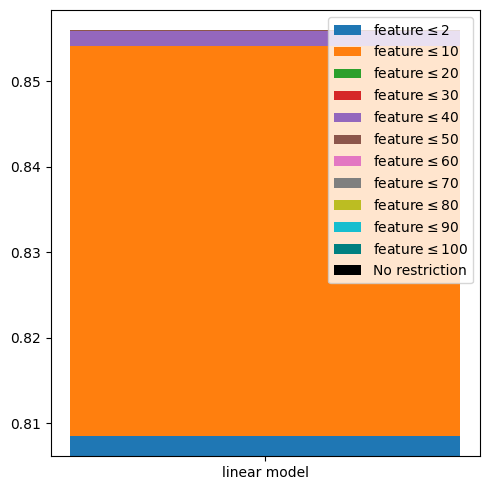

In [14]:
def get_autacs(th):
    pareto_df = max_pareto_front(
        (results_df[results_df["features_used"] <= th]) if th != None else results_df, "transparency", "accuracy"
    ).sort_values("transparency", ascending=False, ignore_index=True)
    pareto_df.loc[len(pareto_df)] = {
        "offload_thrs": 0,
        "transparency": 0,
        "accuracy": pareto_df["accuracy"].iloc[-1],
        "features_used": pareto_df["features_used"].iloc[-1],
    }
    return auc(pareto_df["transparency"], pareto_df["accuracy"])

ax = plt.gca()


feature_filter_list = [2] + list(range(10, 101, 10)) + [None]
autacs = [get_autacs(th) for th in feature_filter_list]
labels = [f"feature$\\leq{th}$" if th is not None else "No restriction" for th in feature_filter_list]
colors = [f"C{i}" for i in range(10)] + ["teal", "black"]

au_max = max(autacs)
au_min = min(autacs)
margin = (au_max - au_min) * 0.05
range_min = au_min - margin
range_max = au_max + margin

for idx, autac in enumerate(autacs):
    print(f"AUTAC with {labels[idx]}:",autac)
    ax.bar(
        [f"linear model"], 
        autac, label=labels[idx], 
        color=colors[idx], 
        zorder=-idx
        )
ax.set_ylim(range_min, range_max)
plt.tight_layout()
plt.legend()
plt.show()